<div style="background-color:#EAF4EC; padding:20px; border-radius:10px;">

<h2 style="color:#2F6F4E; text-align:center; margin-bottom:5px;">
Data Understanding: 
Exploratory Data Analysis (EDA)
</h2>

<h4 style="color:#2F6F4E; text-align:center; margin-top:0;">
Master Thesis – ESG Governance Indicators (EU-27)
</h4>

<p style="font-size:14px; color:#2F6F4E;">
This notebook performs the <strong>Data Understanding / Exploratory Data Analysis (EDA)</strong> step of the CRISP-ML(Q) methodology.<br>
The goal is to obtain a clear overview of the EU-27 Governance dataset before any cleaning or preprocessing.
</p>


<p style="font-size:14px; color:#2F6F4E;">
This notebook does <em>not</em> modify or clean the dataset.<br>
Preprocessing will be done later in <code>03_data_preparation.ipynb</code>.
</p>

</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap

In [2]:
PRIMARY = "#00A651"     # verde elétrico (linha)
BACKGROUND = "#F1FBF5"  # verde muito suave (fundo subtil)
GRID = "#D6EFE3"        # grid leve esverdeado
BLACK = "#000000"       # eixos e texto

In [3]:
DATA_PATH = Path("../../data/processed/esg_gov17_eu27.csv")
df_wide = pd.read_csv(DATA_PATH)

In [4]:
BG = "#EAF4EC"
ACCENT = "#2F6F4E"
TEXT = "#1F2937"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.edgecolor": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "text.color": TEXT,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "grid.color": "#CFE3D7",
    "grid.linestyle": "-",
    "grid.linewidth": 0.8,
})

GREEN_CMAP = LinearSegmentedColormap.from_list("green_theme",[BG, "#BFE3D0", "#6FBF9B", ACCENT])
MAP = LinearSegmentedColormap.from_list("corr_theme",["#8B1E3F", "#F4F5F7", ACCENT]) 

In [5]:
df_wide.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Austria,AUT,Control of Corruption: Estimate,CC.EST,NaN,NaN,NaN,NaN,NaN,NaN,...,1.466502,1.472044,1.496881,1.500820,1.568587,1.521324,1.477709,1.242727,1.258587,1.133653
1,Austria,AUT,Economic and Social Rights Performance Score,SD.ESR.PERF.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.389795,2.410802,2.407398,2.401373,2.407031,NaN,NaN,NaN,NaN,NaN
2,Austria,AUT,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,5.537979,2.648675,4.138268,6.124354,3.480175,...,0.755799,1.303523,2.117220,2.272250,2.484221,1.754976,-6.318255,4.795329,5.277894,-0.954963
3,Austria,AUT,Government Effectiveness: Estimate,GE.EST,NaN,NaN,NaN,NaN,NaN,NaN,...,1.552996,1.450979,1.474811,1.467752,1.456117,1.492126,1.605863,1.528295,1.464923,1.326681
4,Austria,AUT,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,81.000000,83.900000,84.300000,87.900000,87.500000,87.800000,87.500000,92.500000,93.600000,95.300000


<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">

<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
1. Data Integrity  — Do we have the dataset we expect?
</h2>

**1.1 EU-27 Country Coverage**
- The dataset contains **27 unique country names** and **27 unique country codes**.
- All EU-27 Member States are present, with no missing or extra countries.

In [6]:
unique_countries = df_wide["Country Name"].sort_values().unique()
unique_country_codes = df_wide["Country Code"].sort_values().unique()

print(f"Number of unique country names: {len(unique_countries)}")
print(f"Number of unique country codes: {len(unique_country_codes)}")

print("\nCountry names:")
print(unique_countries)

print("\nCountry codes:")
print(unique_country_codes)

Number of unique country names: 27
Number of unique country codes: 27

Country names:
['Austria' 'Belgium' 'Bulgaria' 'Croatia' 'Cyprus' 'Czechia' 'Denmark'
 'Estonia' 'Finland' 'France' 'Germany' 'Greece' 'Hungary' 'Ireland'
 'Italy' 'Latvia' 'Lithuania' 'Luxembourg' 'Malta' 'Netherlands' 'Poland'
 'Portugal' 'Romania' 'Slovak Republic' 'Slovenia' 'Spain' 'Sweden']

Country codes:
['AUT' 'BEL' 'BGR' 'CYP' 'CZE' 'DEU' 'DNK' 'ESP' 'EST' 'FIN' 'FRA' 'GRC'
 'HRV' 'HUN' 'IRL' 'ITA' 'LTU' 'LUX' 'LVA' 'MLT' 'NLD' 'POL' 'PRT' 'ROU'
 'SVK' 'SVN' 'SWE']


**1.2 Governance Indicators**
- The dataset includes **17 unique governance indicators**, matching the expected set from the World Bank Sovereign ESG Data Portal.
- No unexpected indicators were found.
- Indicator codes map **1-to-1** to indicator names (no inconsistencies).

In [7]:
indicators = df_wide[["Indicator Code", "Indicator Name"]].drop_duplicates()

print(f"Number of unique indicators: {indicators.shape[0]}")
indicators.sort_values("Indicator Code")

Number of unique indicators: 17


,Indicator Code,Indicator Name
0,CC.EST,Control of Corruption: Estimate
11,GB.XPD.RSDV.GD.ZS,Research and development expenditure (% of GDP)
3,GE.EST,Government Effectiveness: Estimate
14,IP.JRN.ARTC.SC,Scientific and technical journal articles
6,IP.PAT.RESD,"Patent applications, residents"
4,IT.NET.USER.ZS,Individuals using the Internet (% of population)
2,NY.GDP.MKTP.KD.ZG,GDP growth (annual %)
7,PV.EST,Political Stability and Absence of Violence/Te...
12,RL.EST,Rule of Law: Estimate
10,RQ.EST,Regulatory Quality: Estimate


In [8]:
# Country Code → Country Name mapping
country_name_counts = df_wide.groupby("Country Code")["Country Name"].nunique().sort_values(ascending=False)
print("Number of distinct names per Country Code:")
print(country_name_counts.head(10))

# Indicador Code → Indicator Name mapping
indicator_name_counts = df_wide.groupby("Indicator Code")["Indicator Name"].nunique().sort_values(ascending=False)
print("\nNumber of distinct names per Indicator Code:")
print(indicator_name_counts.head(10))

Number of distinct names per Country Code:
Country Code
AUT    1
IRL    1
SVN    1
SVK    1
ROU    1
PRT    1
POL    1
NLD    1
MLT    1
LVA    1
Name: Country Name, dtype: int64

Number of distinct names per Indicator Code:
Indicator Code
CC.EST               1
RQ.EST               1
SP.UWT.TFRT          1
SM.POP.NETM          1
SL.TLF.CACT.FM.ZS    1
SG.GEN.PARL.ZS       1
SE.ENR.PRSC.FM.ZS    1
SD.ESR.PERF.XQ       1
RL.EST               1
GB.XPD.RSDV.GD.ZS    1
Name: Indicator Name, dtype: int64


In [9]:
dup_mask = df_wide.duplicated(subset=["Country Code", "Indicator Code"], keep=False)
num_duplicates = dup_mask.sum()

print(f"Number of duplicated rows (Country Code + Indicator Code): {num_duplicates}")

if num_duplicates > 0:
    display(df_wide.loc[dup_mask].sort_values(["Country Code", "Indicator Code"]).head(10))


Number of duplicated rows (Country Code + Indicator Code): 0


**1.3 Country and Indicator Consistency**
- Each **Country Code** maps uniquely to a single **Country Name**.
- Each **Indicator Code** maps uniquely to a single **Indicator Name**.
- No duplicated rows were found for any (Country Code, Indicator Code) combination.

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">

<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
2. Temporal Coverage — How is the data distributed over time?
</h2>

**2.1 What years are available in the dataset?**

We identify the full time span covered by the 17 governance indicators.

In [10]:
# Identify columns that correspond to years (wide format)
year_cols = [c for c in df_wide.columns if c.isdigit()]

print("Years detected in dataset:", year_cols[:5], "...", year_cols[-5:])
print(f"Total number of years: {len(year_cols)}")

start_year = min(map(int, year_cols))
end_year = max(map(int, year_cols))

print(f"\nTime span: {start_year} – {end_year}")

Years detected in dataset: ['1960', '1961', '1962', '1963', '1964'] ... ['2019', '2020', '2021', '2022', '2023']
Total number of years: 64

Time span: 1960 – 2023


In [11]:
missing_per_year = df_wide[year_cols].isna().sum()
missing_rate = missing_per_year / df_wide.shape[0]

missing_df = pd.DataFrame({"year": year_cols,"missing": missing_per_year.values,"missing_rate": missing_rate.values})
missing_df.head()


,year,missing,missing_rate
0,1960,432,0.941176
1,1961,417,0.908497
2,1962,417,0.908497
3,1963,417,0.908497
4,1964,417,0.908497


**2.2 Do some years suffer from extensive missing values?**
We measure missingness per year to detect:
- early years with poor coverage,
- periods with incomplete reporting,
- potential structural breaks.

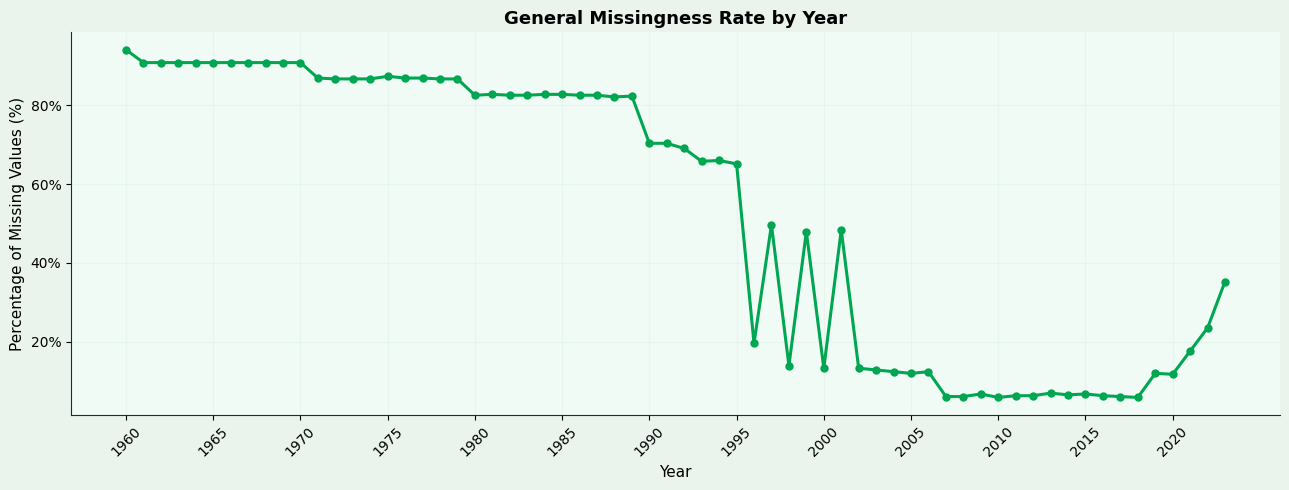

In [12]:
# Ensure year is numeric and sorted
missing_df["year"] = missing_df["year"].astype(int)
missing_df = missing_df.sort_values("year")

fig, ax = plt.subplots(figsize=(13, 5))

# Fundo do gráfico
ax.set_facecolor(BACKGROUND)

# Linha principal (verde elétrico)
ax.plot(
    missing_df["year"],
    missing_df["missing_rate"] * 100,
    marker="o",
    linewidth=2.2,
    markersize=5,
    color=PRIMARY
)

# Títulos e labels (PRETO)
ax.set_title("General Missingness Rate by Year", fontsize=13, color=BLACK)
ax.set_xlabel("Year", color=BLACK)
ax.set_ylabel("Percentage of Missing Values (%)", color=BLACK)

# Eixo X
ax.set_xticks(missing_df["year"][::5])
ax.tick_params(axis="x", rotation=45, colors=BLACK)

# Eixo Y
ax.tick_params(axis="y", colors=BLACK)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Grid suave
ax.grid(True, alpha=0.4, color=GRID)

# Bordas mais clean
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


 **2.3 Has data coverage improved over time?**
We calculate the share of available data per year and visualise it to detect:
- progressive improvement in the 2000s,
- stabilisation periods,
- years to potentially exclude from the analysis.

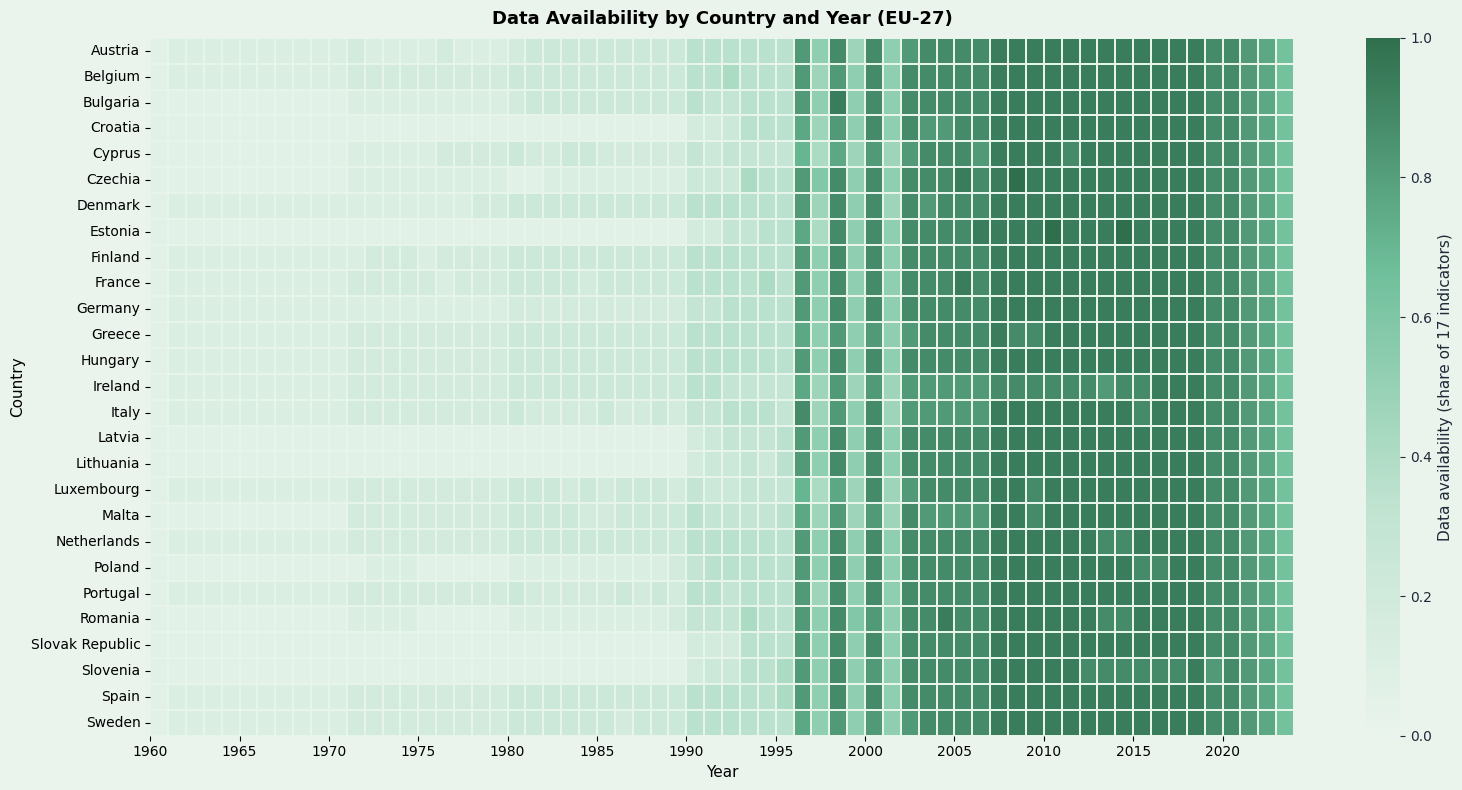

In [13]:
availability_share = (
    df_wide.groupby("Country Name")[year_cols]
    .apply(lambda x: x.notna().mean())
)

fig, ax = plt.subplots(figsize=(16, 8))

# Fundo subtil
ax.set_facecolor("#F1FBF5")

sns.heatmap(
    availability_share,
    cmap=GREEN_CMAP,
    vmin=0, vmax=1,
    linewidths=0.2,
    linecolor="#E6F4EA",
    cbar_kws={"label": "Data availability (share of 17 indicators)"},
    ax=ax
)

# Títulos e labels (PRETO)
ax.set_title("Data Availability by Country and Year (EU-27)", fontsize=13, pad=10, color="black")
ax.set_xlabel("Year", color="black")
ax.set_ylabel("Country", color="black")

# Ticks (PRETO)
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

# X-axis: mostrar de 5 em 5 anos
step = 5  
ax.set_xticks(range(0, len(year_cols), step))
ax.set_xticklabels([year_cols[i] for i in range(0, len(year_cols), step)], rotation=0)

plt.tight_layout()
plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">

<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
3. Indicator Quality — Which indicators have the most issues?
</h2>

In [14]:
# Convert df_wide into long format for indicator-level analysis
year_cols = [c for c in df_wide.columns if c.isdigit()]

df_long = df_wide.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_cols,
    var_name="year",
    value_name="value"
)

df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce")
df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")

print("Long-format table for Indicator Quality analysis:", df_long.shape)
df_long.head()

Long-format table for Indicator Quality analysis: (29376, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,year,value
0,Austria,AUT,Control of Corruption: Estimate,CC.EST,1960,NaN
1,Austria,AUT,Economic and Social Rights Performance Score,SD.ESR.PERF.XQ,1960,NaN
2,Austria,AUT,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,1960,NaN
3,Austria,AUT,Government Effectiveness: Estimate,GE.EST,1960,NaN
4,Austria,AUT,Individuals using the Internet (% of population),IT.NET.USER.ZS,1960,NaN


In [15]:
# ── Summary Statistics Table (para o Cap. 3.2.2 da tese) ──────────────────────

# 1. Filtrar para o período de análise (2000–2023)
df_stats = df_long[df_long["year"] >= 2000].dropna(subset=["value"])

# 2. Calcular estatísticas por indicador
summary = (
    df_stats
    .groupby(["Indicator Code", "Indicator Name"])["value"]
    .agg(
        Mean="mean",
        Std="std",
        Min="min",
        Q25=lambda x: x.quantile(0.25),
        Median="median",
        Q75=lambda x: x.quantile(0.75),
        Max="max",
    )
    .reset_index()
)

# 3. Adicionar Skewness e Kurtosis
skew_kurt = (
    df_stats
    .groupby("Indicator Code")["value"]
    .agg(
        Skew=lambda x: x.skew(),
        Kurt=lambda x: x.kurtosis(),
    )
    .reset_index()
)

summary = summary.merge(skew_kurt, on="Indicator Code")

# 4. Tipo de variável (todos numéricos — ajusta se tiveres ordinais)
type_map = {
    "CC.EST":             "Continuous",
    "SD.ESR.PERF.XQ":    "Continuous",
    "NY.GDP.MKTP.KD.ZG": "Continuous",
    "GE.EST":            "Continuous",
    "IT.NET.USER.ZS":    "Continuous",
    "SM.POP.NETM":       "Continuous",
    "IP.PAT.RESD":       "Continuous",
    "PV.EST":            "Continuous",
    "SG.GEN.PARL.ZS":   "Continuous",
    "SL.TLF.CACT.FM.ZS":"Continuous",
    "RQ.EST":            "Continuous",
    "GB.XPD.RSDV.GD.ZS":"Continuous",
    "RL.EST":            "Continuous",
    "SE.ENR.PRSC.FM.ZS": "Continuous",
    "IP.JRN.ARTC.SC":   "Continuous",
    "SP.UWT.TFRT":       "Continuous",
    "VA.EST":            "Continuous",
}
summary["Data Type"] = summary["Indicator Code"].map(type_map).fillna("Continuous")

# 5. Arredondar para 2 casas decimais e exportar
cols_order = ["Indicator Code","Indicator Name","Data Type",
              "Mean","Std","Min","Q25","Median","Q75","Max","Skew","Kurt"]
summary = summary[cols_order].round(2)

# Ver a tabela
display(summary)

# Guardar em CSV para colar na tese
summary.to_csv("summary_statistics.csv", index=False)
print("Guardado em summary_statistics.csv")

,Indicator Code,Indicator Name,Data Type,Mean,Std,Min,Q25,Median,Q75,Max,Skew,Kurt
0,CC.EST,Control of Corruption: Estimate,Continuous,0.98,0.78,-0.51,0.31,0.86,1.65,2.46,0.19,-1.15
1,GB.XPD.RSDV.GD.ZS,Research and development expenditure (% of GDP),Continuous,1.49,0.89,0.23,0.75,1.25,2.14,3.87,0.72,-0.56
2,GE.EST,Government Effectiveness: Estimate,Continuous,1.07,0.60,-0.36,0.65,1.03,1.58,2.35,-0.13,-0.67
3,IP.JRN.ARTC.SC,Scientific and technical journal articles,Continuous,17280.58,24149.69,45.34,2387.62,7999.14,16896.47,119603.62,2.16,4.22
4,IP.PAT.RESD,"Patent applications, residents",Continuous,3529.86,9419.27,1.00,169.50,683.00,2162.00,51736.00,4.09,16.20
5,IT.NET.USER.ZS,Individuals using the Internet (% of population),Continuous,65.27,24.59,3.61,47.70,72.20,85.32,99.30,-0.73,-0.52
6,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),Continuous,2.50,3.90,-16.04,0.88,2.58,4.45,24.62,-0.27,4.34
7,PV.EST,Political Stability and Absence of Violence/Te...,Continuous,0.76,0.39,-0.47,0.51,0.79,1.01,1.76,-0.19,0.06
8,RL.EST,Rule of Law: Estimate,Continuous,1.07,0.61,-0.27,0.59,1.05,1.64,2.12,-0.21,-0.96
9,RQ.EST,Regulatory Quality: Estimate,Continuous,1.15,0.45,-0.12,0.81,1.15,1.55,2.04,-0.12,-0.78


Guardado em summary_statistics.csv


In [16]:
missing_by_indicator = (df_long.assign(is_missing=df_long["value"].isna()).groupby("Indicator Code")["is_missing"].mean().sort_values(ascending=False))
print("Missingness by indicator (%):")
display((missing_by_indicator * 100).round(1))

Missingness by indicator (%):


Indicator Code
SP.UWT.TFRT          98.8
SD.ESR.PERF.XQ       81.2
CC.EST               60.9
PV.EST               60.9
RQ.EST               60.9
RL.EST               60.9
GE.EST               60.9
VA.EST               60.9
GB.XPD.RSDV.GD.ZS    59.4
SG.GEN.PARL.ZS       58.2
IP.JRN.ARTC.SC       57.8
IT.NET.USER.ZS       48.6
SL.TLF.CACT.FM.ZS    46.9
IP.PAT.RESD          44.0
SE.ENR.PRSC.FM.ZS    35.8
NY.GDP.MKTP.KD.ZG    19.8
SM.POP.NETM           0.0
Name: is_missing, dtype: float64

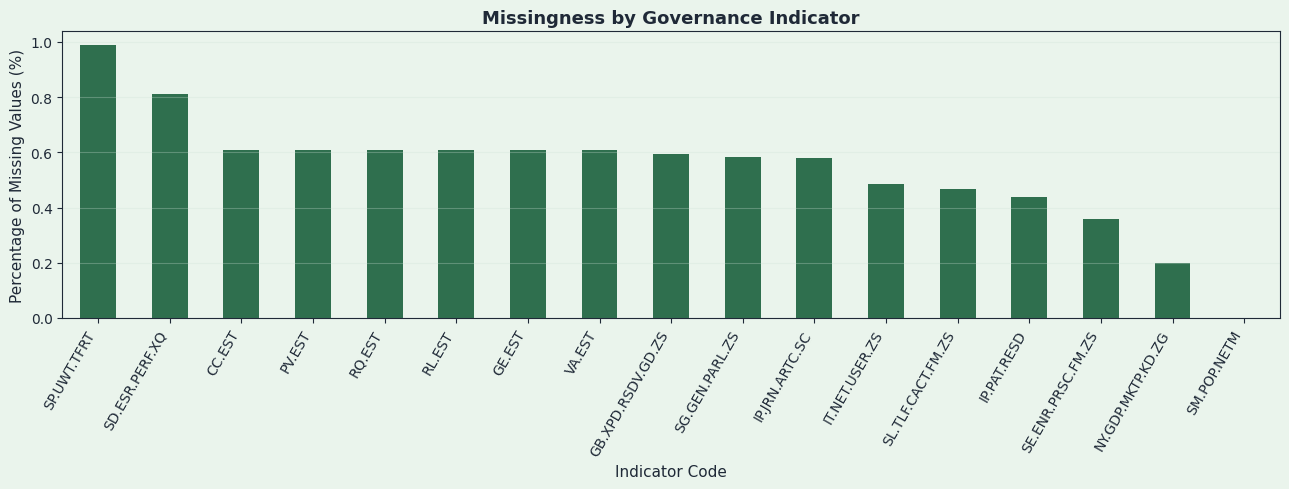

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))

missing_by_indicator.plot(
    kind="bar",
    color=ACCENT,
    ax=ax
)

ax.set_title("Missingness by Governance Indicator", fontsize=13)
ax.set_xlabel("Indicator Code")
ax.set_ylabel("Percentage of Missing Values (%)")

# Fix x-axis labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=60,
    ha="right"
)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()



In [18]:
def robust_z(x):
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med)) + 1e-9
    return 0.6745 * (x - med) / mad

df_long["robust_z"] = df_long.groupby("Indicator Code")["value"].transform(robust_z)

outliers = df_long[np.abs(df_long["robust_z"]) >= 3]

print("Number of extreme outliers (|z| ≥ 3):", outliers.shape[0])
outliers.head()


Number of extreme outliers (|z| ≥ 3): 670


,Country Name,Country Code,Indicator Name,Indicator Code,year,value,robust_z
158,France,FRA,Net migration,SM.POP.NETM,1960,143032.0,7.335687
175,Germany,DEU,Net migration,SM.POP.NETM,1960,212666.0,11.023657
243,Italy,ITA,Net migration,SM.POP.NETM,1960,-140765.0,-7.694824
362,Portugal,PRT,Net migration,SM.POP.NETM,1960,-95886.0,-5.317934
379,Romania,ROU,Net migration,SM.POP.NETM,1960,-55397.0,-3.173548


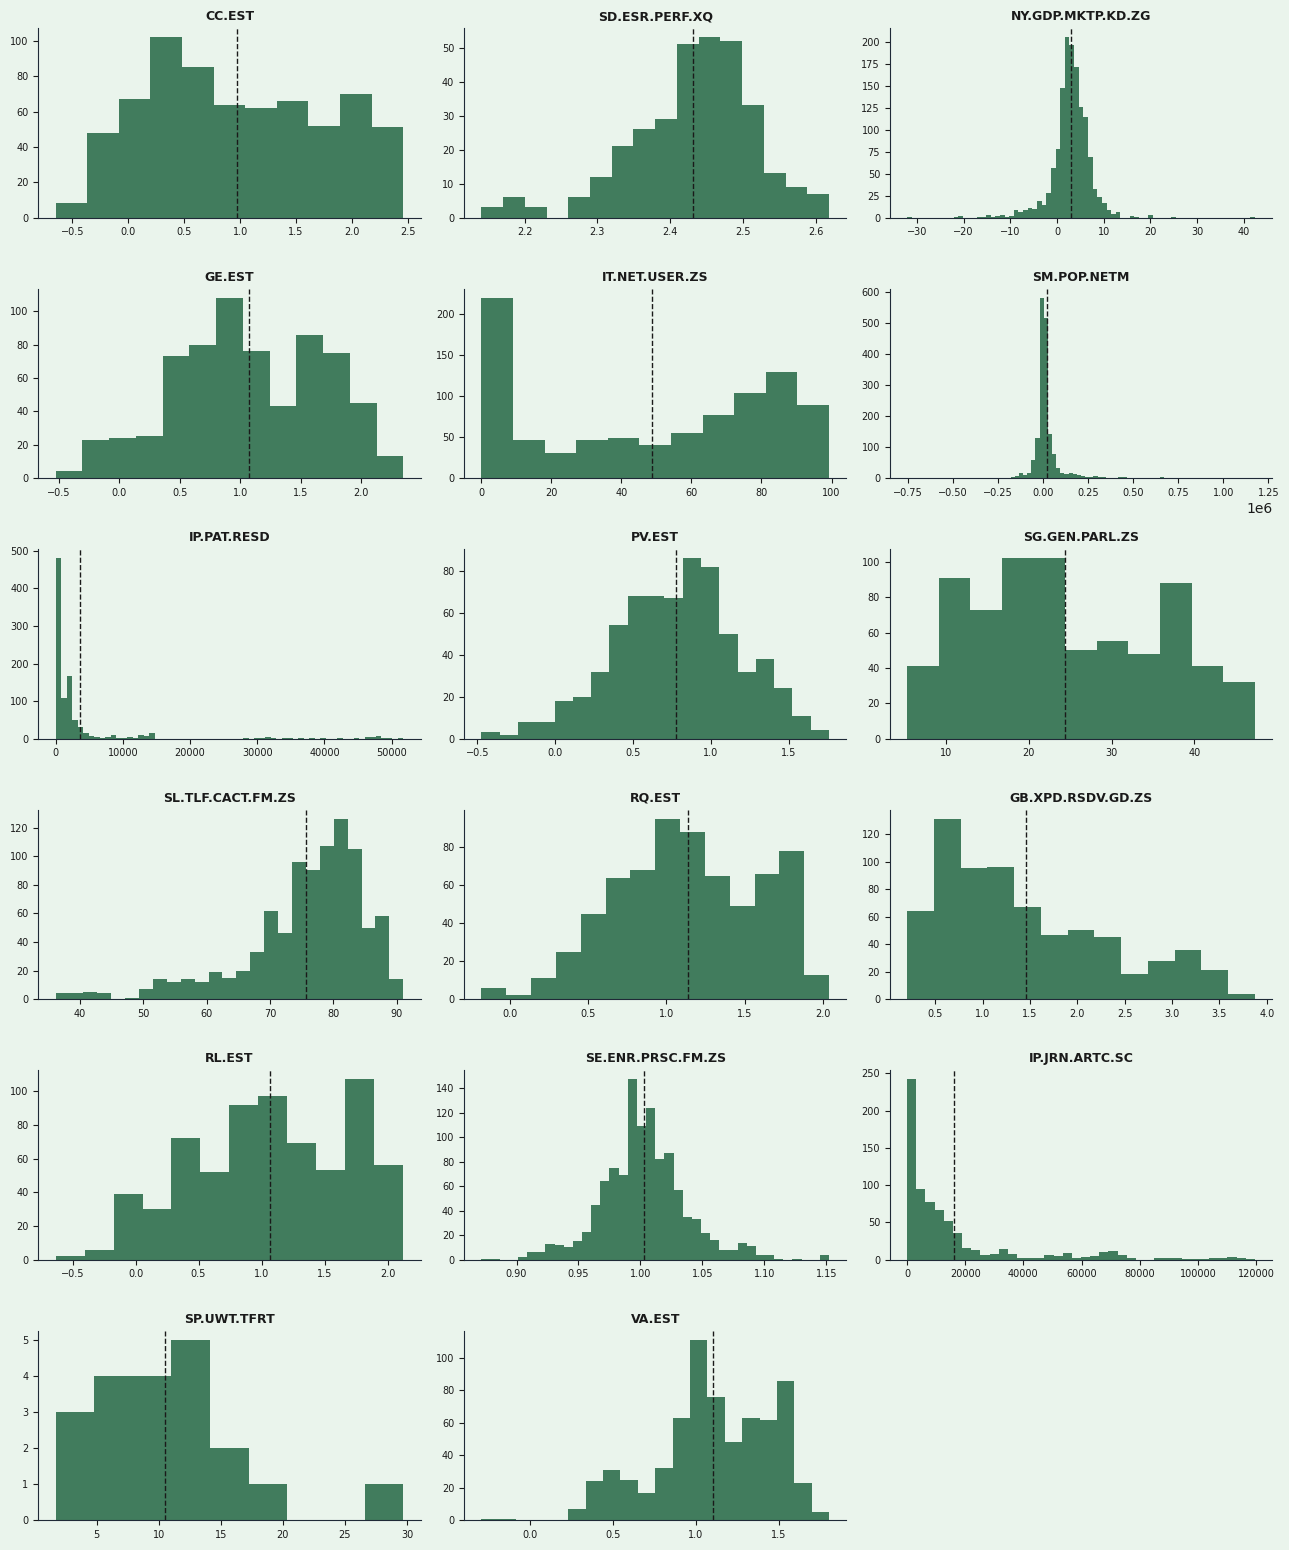

In [19]:
BACKGROUND = "#EAF4EC"
PRIMARY     = "#2F6F4E"
BLACK       = "#1a1a1a"

unique_inds = df_long["Indicator Code"].unique()
n = len(unique_inds)

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(13, rows * 2.6))
axes = axes.flatten()

fig.patch.set_facecolor(BACKGROUND)

for i, ind in enumerate(unique_inds):
    subset = df_long.loc[
        df_long["Indicator Code"] == ind, "value"
    ].dropna()

    axes[i].set_facecolor(BACKGROUND)

    axes[i].hist(
        subset,
        bins="auto",
        color=PRIMARY,
        alpha=0.9
    )

    axes[i].axvline(
        subset.mean(),
        color=BLACK,
        linestyle="--",
        linewidth=1
    )

    axes[i].set_title(ind, fontsize=9, color=BLACK)
    axes[i].tick_params(axis="both", labelsize=7, colors=BLACK)
    axes[i].set_ylabel("")
    axes[i].grid(False)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- The indicators display **heterogeneous distributional shapes**, reflecting differences in scale, reporting practices, and structural country characteristics.  
- Several governance indicators (e.g., **CC.EST**, **GE.EST**, **RQ.EST**, **RL.EST**, **PV.EST**) show **fairly symmetric or mildly skewed distributions**, suggesting stable reporting across countries and time.
- Some indicators exhibit **strong skewness and heavy tails**, particularly:
  - **SM.POP.NETM** (Net migration): extremely high variance and large outliers, especially in earlier decades.
  - **IP.PAT.RESD** and **IP.JRN.ARTC.SC**: right-tailed distributions driven by high-performing innovation economies.
  - **NY.GDP.MKTP.KD.ZG**: asymmetric behaviour reflecting economic expansions and recessions.
- A few indicators show **multimodal distributions**, indicating structural differences between Western and Eastern EU member states.
- These distributional patterns confirm the need for **scaling/normalisation** prior to modelling and clustering.
- Outliers identified through robust z-scores (|z| ≥ 3) mainly affect indicators with naturally high variability (e.g., migration, innovation output), and likely reflect **true economic or demographic events**, not errors.

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">

<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
4. Latent Structure — Are there hidden patterns or natural clusters?
</h2>

In [20]:
# Pivot: rows = country, columns = indicator, values = mean over available years
pivot = (
    df_long
    .groupby(["Country Code", "Indicator Code"])["value"]
    .mean()
    .unstack("Indicator Code")
)

print("Country–indicator matrix shape:", pivot.shape)
pivot.head()

Country–indicator matrix shape: (27, 17)


Indicator Code,CC.EST,GB.XPD.RSDV.GD.ZS,GE.EST,IP.JRN.ARTC.SC,IP.PAT.RESD,IT.NET.USER.ZS,NY.GDP.MKTP.KD.ZG,PV.EST,RL.EST,RQ.EST,SD.ESR.PERF.XQ,SE.ENR.PRSC.FM.ZS,SG.GEN.PARL.ZS,SL.TLF.CACT.FM.ZS,SM.POP.NETM,SP.UWT.TFRT,VA.EST
Country Code,,,,,,,,,,,,,,,,,
AUT,1.628059,2.551012,1.648371,10423.043333,2135.785714,52.929912,2.629148,1.082411,1.824746,1.478954,2.379391,0.956962,32.327869,76.311700,25645.578125,NaN,1.387998
BEL,1.433782,2.269293,1.519270,13836.461481,721.452381,52.609062,2.583450,0.755828,1.352460,1.265565,2.458279,1.040585,34.246914,74.571142,26334.921875,3.40,1.356918
BGR,-0.208215,0.594413,-0.018493,2602.598148,641.023810,34.271776,1.851993,0.289915,-0.117440,0.523768,2.319482,0.984537,21.435185,81.144924,-15878.281250,29.70,0.450525
CYP,0.895646,0.454930,1.135167,693.830370,5.400000,43.038500,4.941588,0.476573,0.919020,1.111882,2.489035,1.001484,12.830688,74.151869,4874.781250,NaN,1.009746
CZE,0.460191,1.458684,0.916649,10864.789630,709.103448,46.486281,1.847082,0.947504,0.961680,1.138330,2.435670,1.019735,19.092593,74.245474,9670.078125,9.45,0.976315


In [21]:
year_cols = [c for c in df_wide.columns if c.isdigit()]
indicator_year = (
    df_wide
    .groupby("Indicator Code")[year_cols]
    .mean()
)


In [22]:
corr = indicator_year.T.corr(method="pearson")


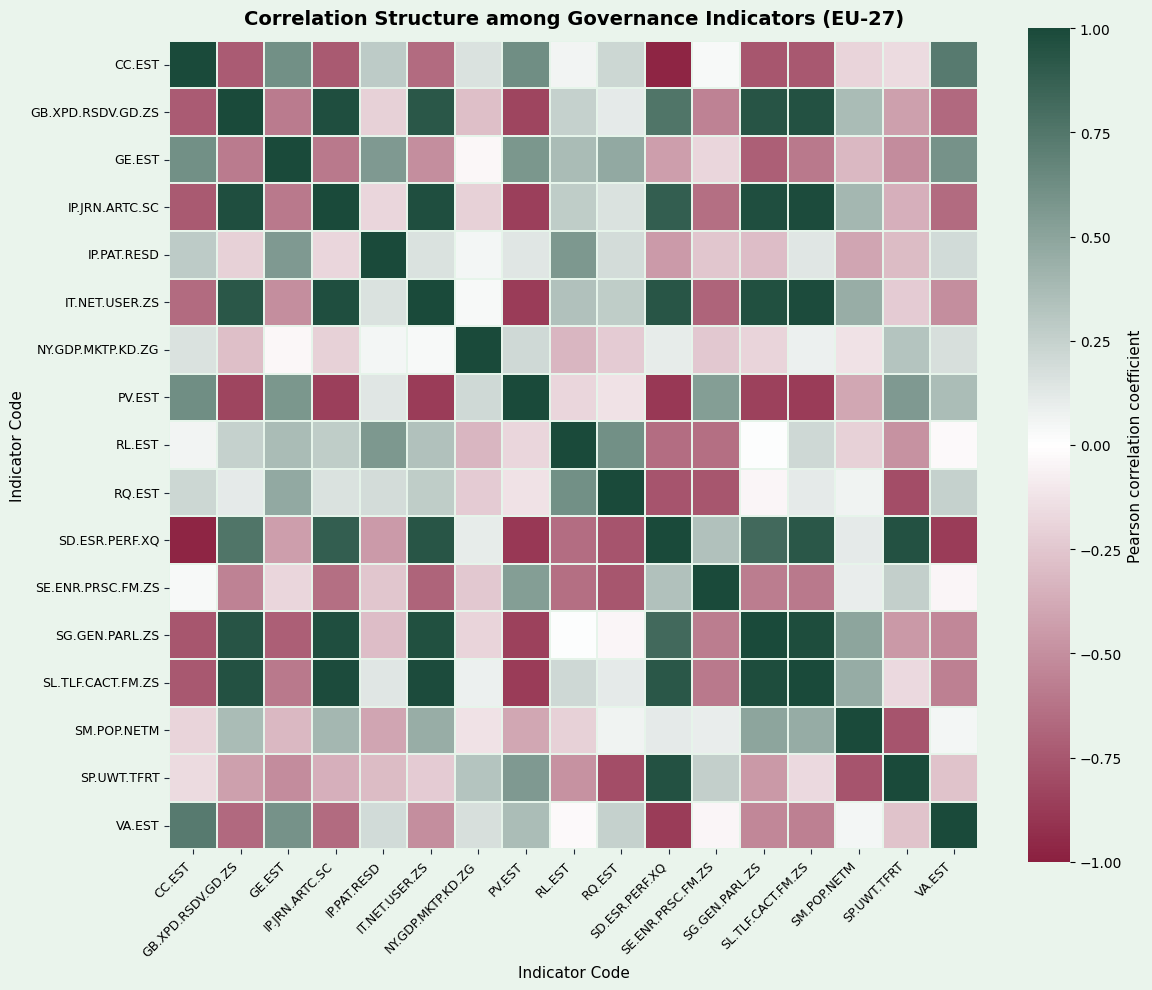

In [23]:
import matplotlib.colors as mcolors

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom",
    ["#8B2040", "#ffffff", "#1a4a3a"]
)

plt.figure(figsize=(12, 10))

ax = sns.heatmap(
    corr,
    cmap=custom_cmap,
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.25,
    linecolor="#E6F4EA",
    cbar_kws={"label": "Pearson correlation coefficient"}
)

ax.set_facecolor("#EAF4EC")

plt.title(
    "Correlation Structure among Governance Indicators (EU-27)",
    fontsize=14,
    pad=12,
    color="black"
)

plt.xlabel("Indicator Code", color="black")
plt.ylabel("Indicator Code", color="black")
plt.xticks(rotation=45, ha="right", fontsize=9, color="black")
plt.yticks(fontsize=9, color="black")

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color("black")
cbar.ax.tick_params(colors="black")

plt.tight_layout()
plt.show()